In [1]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [2]:
adata = sc.read_h5ad('../data/mtDNA_DSB_5k_clustered_higher_res.h5ad')

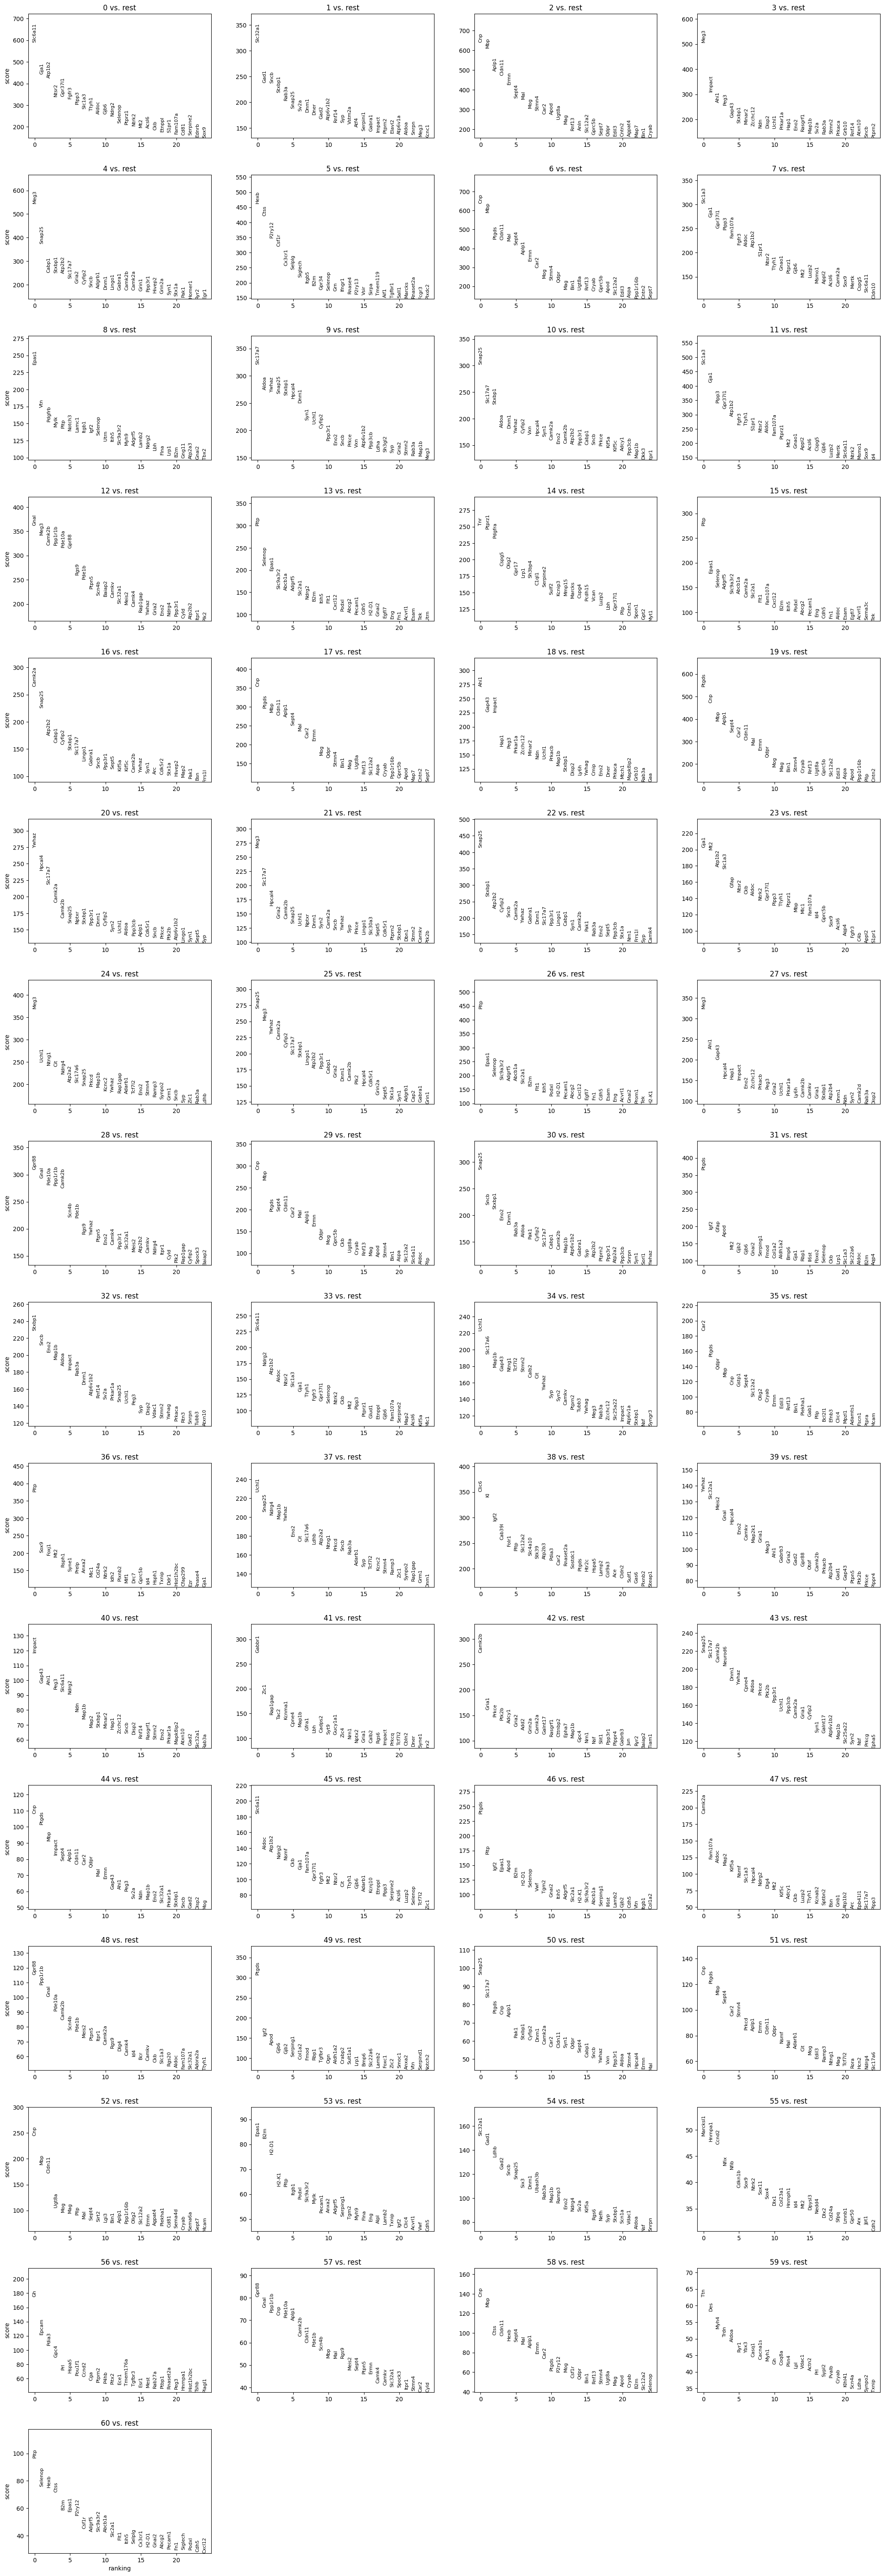

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,0,Slc6a11,590.182251,3.965665,0.0,0.0
1,0,Gja1,443.446381,3.272271,0.0,0.0
2,0,Atp1b2,425.078522,2.690120,0.0,0.0
3,0,Ntsr2,341.129150,2.914672,0.0,0.0
4,0,Gpr37l1,340.414032,3.034781,0.0,0.0


In [3]:
# --- Find marker genes per cluster ---
sc.tl.rank_genes_groups(adata, groupby="leiden_3", method="t-test")
sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False)

# get a tidy table of top markers
markers = sc.get.rank_genes_groups_df(adata, group=None)
markers.head()

In [4]:
marker_genes = pd.DataFrame({
    group: adata.uns['rank_genes_groups']['names'][group][:20]
    for group in adata.uns['rank_genes_groups']['names'].dtype.names
})


In [5]:
for col in marker_genes.columns: 
    print(col)
    genes = marker_genes[col].tolist()
    print(" ".join(genes))
    print(' ')

0
Slc6a11 Gja1 Atp1b2 Ntsr2 Gpr37l1 Fgfr3 Plpp3 Slc1a3 Ttyh1 Aldoc Gjb6 Ndrg2 Selenop Ptprz1 Ntrk2 Mt2 Acsl6 Ckb Etnppl S1pr1
 
1
Slc32a1 Gad1 Sncb Stxbp1 Rab3a Snap25 Sv2a Dnm1 Dner Gad2 Atp6v1b2 Rnf14 Syp Vstm2a Atf4 Serpini1 Gabra1 Impact Ptprn2 Elavl2
 
2
Cnp Mbp Aplp1 Cldn11 Ermn Sept4 Mal Mog Stmn4 Car2 Apod Ugt8a Mag Rnf13 Anln Slc12a2 Gprc5b Sept7 Qdpr Edil3
 
3
Meg3 Impact Ahi1 Peg3 Gap43 Stxbp1 Minar2 Zcchc12 Ndn Disp2 Uchl1 Prkar1a Hap1 Eno2 Rasgrf1 Map1b Sv2a Rab3a Stmn2 Prkaca
 
4
Meg3 Snap25 Cabp1 Stxbp1 Atp2b2 Slc17a7 Gria2 Cyfip2 Sncb Adgrb1 Dnm1 Lingo1 Gabra1 Camk2b Camk2a Grin1 Ppp3r1 Hivep2 Grin2a Syn1
 
5
Hexb Ctss P2ry12 Csf1r Cx3cr1 Selplg Siglech Itgb5 B2m Gpr34 Selenop Grn Ifngr1 Rnase4 P2ry13 Vsir Sirpa Tmem119 Aif1 Tgfbr1
 
6
Cnp Mbp Ptgds Cldn11 Mal Sept4 Aplp1 Ermn Car2 Mog Stmn4 Qdpr Mag Bin1 Ugt8a Rnf13 Cryab Gprc5b Apod Slc12a2
 
7
Slc1a3 Gja1 Gpr37l1 Plpp3 Fam107a Fgfr3 Aldoc Atp1b2 S1pr1 Ntsr2 Ttyh1 Gnao1 Ptprz1 Gjb6 Mt2 Luzp2 Msmo1 Appl2 Acsl6 Camk2a
 

In [6]:
from mllmcelltype import annotate_clusters, setup_logging

In [7]:
from dotenv import load_dotenv
import os

load_dotenv()  # will read .env into environment
api_key = os.getenv("../OPENAI_API_KEY")

In [8]:
marker_genes = marker_genes.T

In [9]:
marker_genes = marker_genes.reset_index().rename(columns={'index':'cluster'})

In [10]:
marker_genes = marker_genes.set_index("cluster").T.to_dict("list")

In [11]:
import os

# Annotate clusters with a single model
annotations = annotate_clusters(
    marker_genes=marker_genes,  # DataFrame or dictionary of marker genes
    species='mouse',               # Organism species
    provider='openai',            # LLM provider
    model='gpt-4o-mini',               # Specific model
    tissue='brain'                #Tissue context (optional but recommended)
)

# Print annotations
for cluster, annotation in annotations.items():
    print(f"Cluster {cluster}: {annotation}")

2025-10-28 10:28:11 - llmcelltype - INFO - Logging initialized. Log file: /Users/christoffer/.llmcelltype/logs/llmcelltype_20251028_102811.log
2025-10-28 10:28:11 - llmcelltype - INFO - Starting annotation with provider: openai
2025-10-28 10:28:11 - llmcelltype - INFO - Found 61 clusters
2025-10-28 10:28:11 - llmcelltype - INFO - Creating prompt for 61 clusters
2025-10-28 10:28:11 - llmcelltype - INFO - Generated prompt with 9827 characters
2025-10-28 10:28:11 - llmcelltype - INFO - Loaded results from cache (version 1.0): /Users/christoffer/.llmcelltype/cache/e3f81b253e861997688e99a553f6581c.json
2025-10-28 10:28:11 - llmcelltype - INFO - Using cached results
2025-10-28 10:28:11 - llmcelltype - INFO - Successfully parsed response in 'Cluster X: Annotation' format


Cluster 0: Astrocytes
Cluster 1: GABAergic Neurons
Cluster 2: Oligodendrocytes
Cluster 3: Neurons
Cluster 4: Excitatory Neurons
Cluster 5: Microglia
Cluster 6: Oligodendrocytes
Cluster 7: Astrocytes
Cluster 8: Endothelial Cells
Cluster 9: Excitatory Neurons
Cluster 10: Excitatory Neurons
Cluster 11: Astrocytes
Cluster 12: Medium Spiny Neurons
Cluster 13: Endothelial Cells
Cluster 14: Oligodendrocyte Precursor Cells
Cluster 15: Endothelial Cells
Cluster 16: Excitatory Neurons
Cluster 17: Oligodendrocytes
Cluster 18: Neurons
Cluster 19: Oligodendrocytes
Cluster 20: Excitatory Neurons
Cluster 21: Excitatory Neurons
Cluster 22: Excitatory Neurons
Cluster 23: Astrocytes
Cluster 24: Neurons
Cluster 25: Excitatory Neurons
Cluster 26: Endothelial Cells
Cluster 27: Neurons
Cluster 28: Medium Spiny Neurons
Cluster 29: Oligodendrocytes
Cluster 30: Excitatory Neurons
Cluster 31: Astrocytes
Cluster 32: Neurons
Cluster 33: Astrocytes
Cluster 34: Neurons
Cluster 35: Oligodendrocytes
Cluster 36: Astro

In [12]:
adata.obs['cell_class'] = adata.obs['leiden_3'].map(annotations)

... storing 'cell_class' as categorical


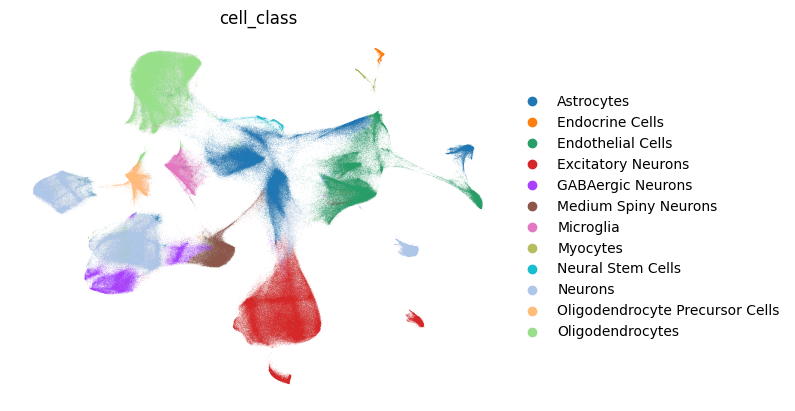

In [13]:
sc.pl.umap(adata, color='cell_class', frameon=False)

In [14]:
spatial = np.array(adata.obs[['x_centroid','y_centroid']])
adata.obsm['spatial'] = spatial

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec

def plot_spatial_compact(
    ad,
    color="leiden_2",
    groupby="sample_id",
    spot_size=18,
    cols=3,
    height=8,
    legend_col_width=1.2,
    palette=None,          # <- NEW: dict {category: "#hex"} or list in desired order
):
    # --- categories from the FULL object (freeze order) ---
    cats = ad.obs[color].astype("category").cat.categories

    # --- build a shared color list in that order ---
    if isinstance(palette, dict):
        cols_list = [palette[c] for c in cats]
    elif isinstance(palette, (list, tuple)):
        if len(palette) < len(cats):
            raise ValueError("Palette list shorter than number of categories.")
        cols_list = list(palette)[:len(cats)]
    elif f"{color}_colors" in ad.uns:
        # reuse existing palette if present on the full object
        cols_list = list(ad.uns[f"{color}_colors"])
        if len(cols_list) != len(cats):
            raise ValueError(f"{color}_colors length does not match categories.")
    else:
        base = sc.pl.palettes.default_64 if hasattr(sc.pl.palettes, "default_64") else sc.pl.palettes.default_102
        reps = int(np.ceil(len(cats) / len(base)))
        cols_list = (base * reps)[:len(cats)]

    # store on the full object too (handy if you plot elsewhere later)
    ad.uns[f"{color}_colors"] = cols_list

    # --- layout ---
    sids = list(ad.obs[groupby].unique())
    n = len(sids)
    rows = int(np.ceil(n / cols))

    panel_w = height * cols * 0.6 / rows
    fig_w = panel_w + legend_col_width
    fig = plt.figure(figsize=(fig_w, height), constrained_layout=False)

    gs = GridSpec(
        rows, cols + 1, figure=fig,
        width_ratios=[1]*cols + [legend_col_width / (fig_w - legend_col_width)],
        wspace=0.02, hspace=0.02
    )

    # --- panels ---
    for i, sid in enumerate(sids):
        r, c = divmod(i, cols)
        ax = fig.add_subplot(gs[r, c])

        ad_sub = ad[ad.obs[groupby] == sid].copy()

        # CRUCIAL: force identical categories & palette on each subset
        ad_sub.obs[color] = ad_sub.obs[color].astype("category")
        ad_sub.obs[color] = ad_sub.obs[color].cat.set_categories(cats)
        ad_sub.uns[f"{color}_colors"] = cols_list

        sc.pl.spatial(
            ad_sub, color=color, spot_size=spot_size,
            show=False, ax=ax, legend_loc=None, frameon=False, title=str(sid)
        )
        ax.set_xlabel(""); ax.set_ylabel("")
        ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

    # blank unused
    for j in range(n, rows*cols):
        r, c = divmod(j, cols)
        fig.add_subplot(gs[r, c]).axis("off")

   # --- legend ---
    ax_leg = fig.add_subplot(gs[:, -1])
    ax_leg.axis("off")
    handles = [
        Line2D([0], [0], marker='o', color='w',
               markerfacecolor=cols_list[k], markersize=7, label=str(cat))
        for k, cat in enumerate(cats)
    ]
    ax_leg.legend(handles=handles, title=color, frameon=False, loc="center left")

    fig.subplots_adjust(left=0.01, right=0.98, top=0.98, bottom=0.02, wspace=0.02, hspace=0.02)

    # RETURN instead of showing
    return fig

In [16]:
list(adata.obs['run'].unique())

['output-XETG00045__0060539__RB4282__20250917__105852',
 'output-XETG00045__0060539__RB4350__20250917__105852',
 'output-XETG00045__0060539__RB4401__20250917__105852',
 'output-XETG00045__0060539__RB4403__20250917__105852',
 'output-XETG00045__0060539__RB4405__20250917__105852',
 'output-XETG00045__0060539__RB4498__20250917__105852',
 'output-XETG00045__0060541__RB4620__20250917__105852',
 'output-XETG00045__0060541__RB4627__20250917__105852',
 'output-XETG00045__0060541__RB4630__20250917__105852',
 'output-XETG00045__0060541__RB4653__20250917__105852',
 'output-XETG00045__0060541__RB4658__20250917__105852',
 'output-XETG00045__0060541__RB4676__20250917__105852']

In [17]:
adata.obs["sample_id"] = adata.obs["run"].str.extract(r"__([A-Za-z0-9]+)__\d{8}__")


In [38]:
import matplotlib.pyplot as plt
import os

out_dir = "../results/figures"
os.makedirs(out_dir, exist_ok=True)

for domain in ["cell_class"]:
    if domain in adata.obs.columns:
        print(f"Plotting and saving: {domain}")
        fig = plot_spatial_compact(
            adata,
            color=domain,
            groupby="sample_id",
            spot_size=20,
            cols=6,
            height=8,
            legend_col_width=1.0,
        )
        save_base = os.path.join(out_dir, f"spatial_{domain}")
        for ext in ["png"]:
            fig.savefig(f"{save_base}.{ext}", bbox_inches="tight", dpi=300)
        plt.close(fig)
    else:
        print(f"Skipping {domain}: not in adata.obs")

Plotting and saving: cell_class


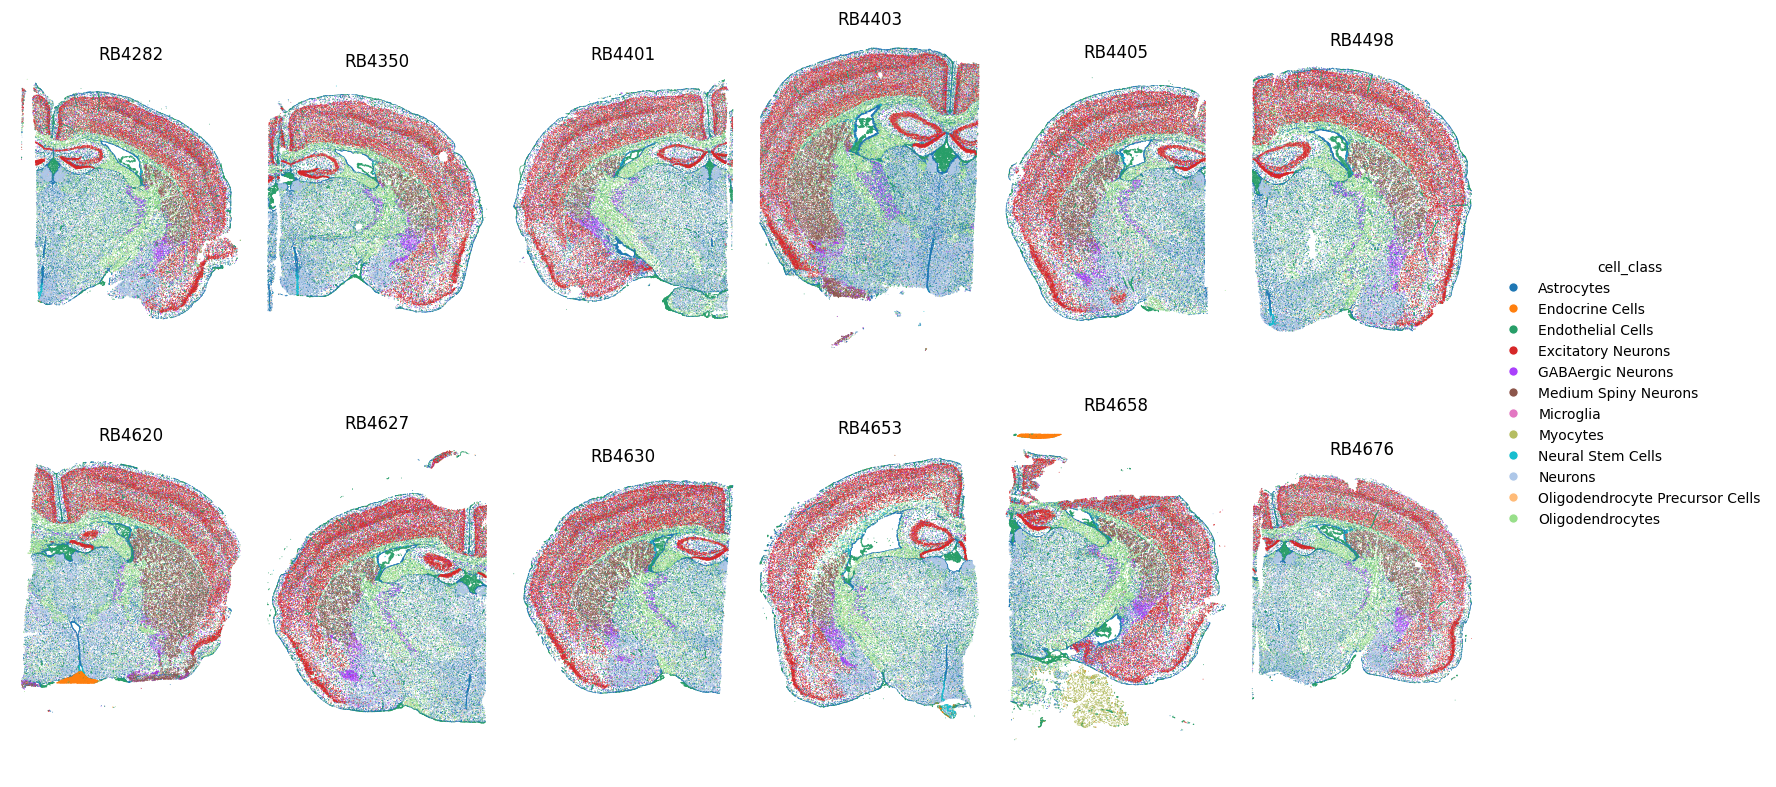

In [39]:
for domain in ['cell_class']:
    if domain in adata.obs.columns: 
        plot_spatial_compact(adata, color=domain, groupby="sample_id",spot_size=20,
            cols=6,
            height=8,
            legend_col_width=1.0,)
    else:
        continue

... storing 'sample_id' as categorical


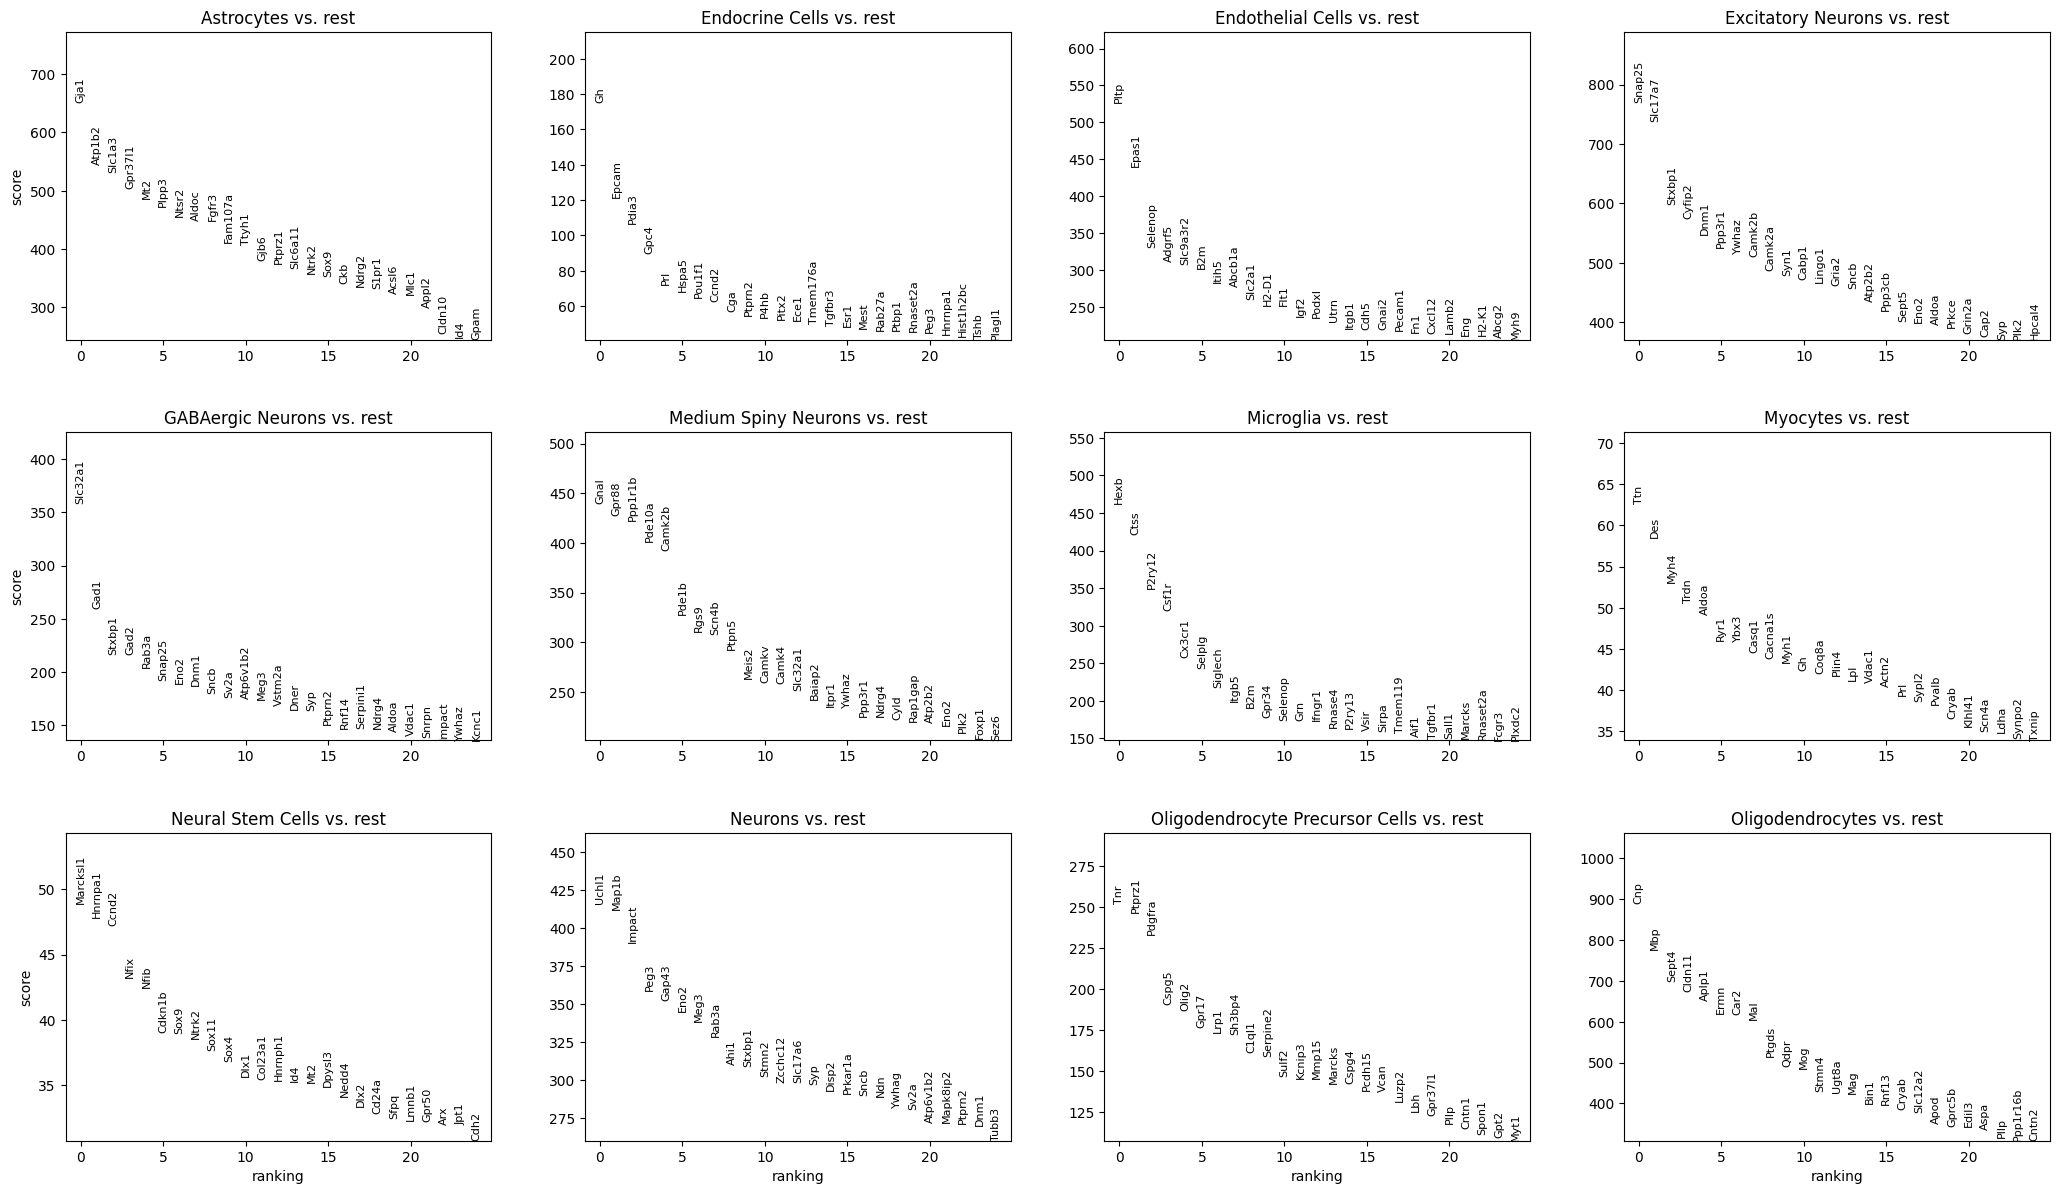

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,Astrocytes,Gja1,650.437500,3.801551,0.0,0.0
1,Astrocytes,Atp1b2,544.533569,2.479298,0.0,0.0
2,Astrocytes,Slc1a3,530.276550,2.802895,0.0,0.0
3,Astrocytes,Gpr37l1,502.970612,3.402809,0.0,0.0
4,Astrocytes,Mt2,487.255890,2.358132,0.0,0.0


In [19]:
# --- Find marker genes per cluster ---
sc.tl.rank_genes_groups(adata, groupby="cell_class", method="t-test")
sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False)

# get a tidy table of top markers
markers = sc.get.rank_genes_groups_df(adata, group=None)
markers.head()

In [20]:
marker_genes = pd.DataFrame({
    group: adata.uns['rank_genes_groups']['names'][group][:4]
    for group in adata.uns['rank_genes_groups']['names'].dtype.names
})


In [21]:
cellclass_markers_top4 = {}
for col in marker_genes.columns: 
    print(col)
    genes = marker_genes[col].tolist()
    print(" ".join(genes))
    print(' ')
    cellclass_markers_top4[col] = genes

Astrocytes
Gja1 Atp1b2 Slc1a3 Gpr37l1
 
Endocrine Cells
Gh Epcam Pdia3 Gpc4
 
Endothelial Cells
Pltp Epas1 Selenop Adgrf5
 
Excitatory Neurons
Snap25 Slc17a7 Stxbp1 Cyfip2
 
GABAergic Neurons
Slc32a1 Gad1 Stxbp1 Gad2
 
Medium Spiny Neurons
Gnal Gpr88 Ppp1r1b Pde10a
 
Microglia
Hexb Ctss P2ry12 Csf1r
 
Myocytes
Ttn Des Myh4 Trdn
 
Neural Stem Cells
Marcksl1 Hnrnpa1 Ccnd2 Nfix
 
Neurons
Uchl1 Map1b Impact Peg3
 
Oligodendrocyte Precursor Cells
Tnr Ptprz1 Pdgfra Cspg5
 
Oligodendrocytes
Cnp Mbp Sept4 Cldn11
 


In [25]:
adata.X.max()

3.894839

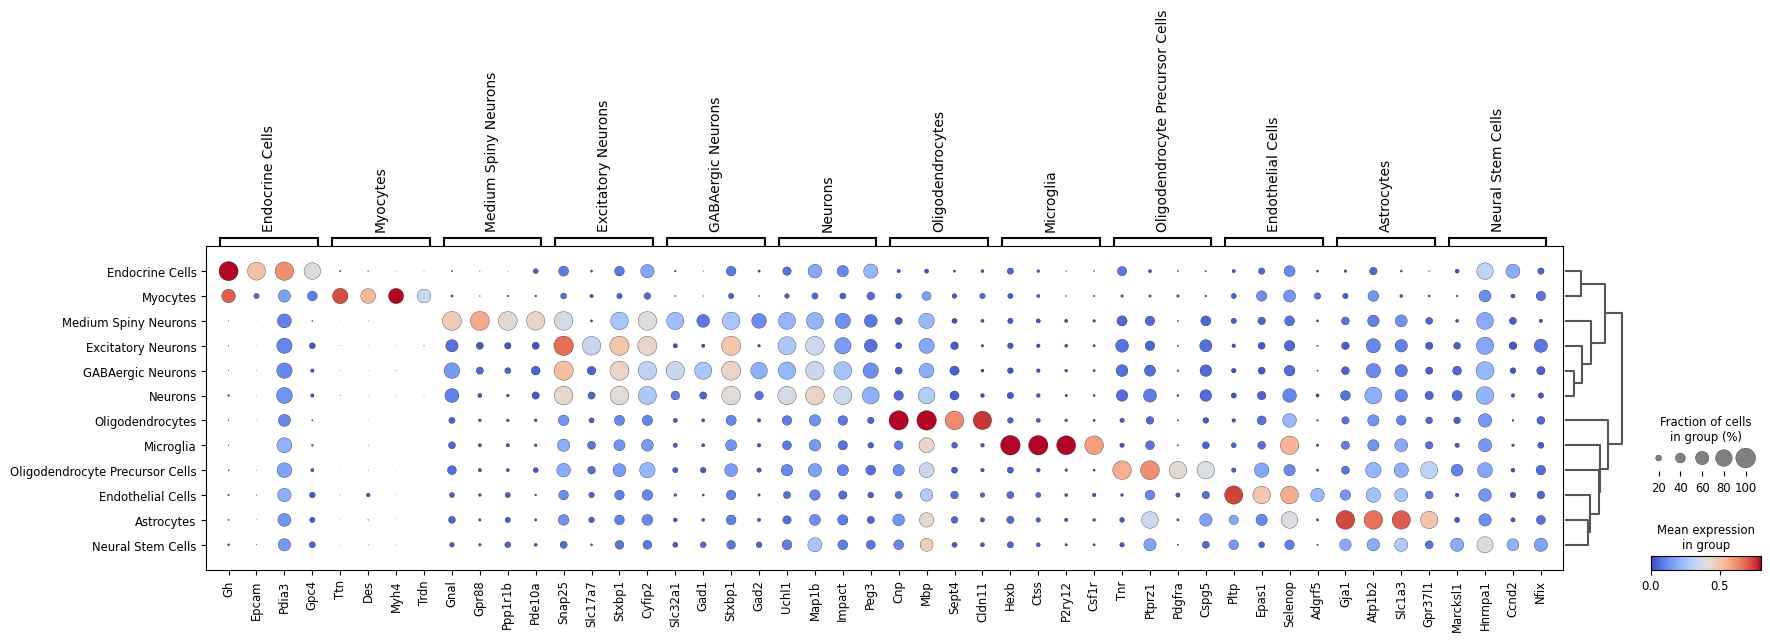

In [30]:
sc.pl.dotplot(
    adata,
    var_names=cellclass_markers_top4,
    groupby="cell_class",
    color_map="coolwarm",
    vmax = 0.8,
    vmin = 0, 
    dendrogram=True
)

In [29]:
adata.write('../data/mtDNA_DSB_5k_clustered_higher_res_LLM_anno.h5ad')

... storing 'sample_id' as categorical
